# Case 3: $\Psi_n$ / IF-expansion diagnostic (Zhong–Wang Thm 3.3)

New notebook only. **Does not modify** existing notebooks, `run/`, or `consistency_plots/`.

Reloads saved Case-3 fits and records Theorist's proof-piece terms:

1. $\sqrt{n}\Psi_n(0,0)$ — oracle score
2. $\sqrt{n}\Psi_n(\hat\xi,\hat h)$ — score at DPLQR fit
3. $\sqrt{n}\Psi_{0,N}(\hat\xi,\hat h)$ — large independent eval sample
4. $\Sigma_2\sqrt{n}\hat\xi$
5. $\mathrm{Gap}_{EP}=\sqrt{n}\Psi_{0,N}+\sqrt{n}\Psi_n(0,0)$
6. $\mathrm{Gap}_{Taylor}=\sqrt{n}\Psi_{0,N}-\Sigma_2\sqrt{n}\hat\xi$
7. $C_n=\sqrt{n}P_n[f_0\tilde X(\hat m-m_0)]$
8. $R2_n=\sqrt{n}\|\hat m-m_0\|_{n,2}^2$
9. $\mathrm{IF}_{resid}=\Sigma_2\sqrt{n}\hat\xi+\sqrt{n}\Psi_n(0,0)$ (also `IF_resid_2Sigma` with $2\Sigma_2$)
10. Same with profiled $\hat\theta=\arg\min_\theta P_n\rho_\tau(Y-X\theta-\hat m)$

Primary means vs $n$ (esp. $2000\to4000$ @ 1000 epochs): $\sqrt{n}\xi_1$, $C_{n,1}$, Gap_Taylor$_1$, Gap_EP$_1$, IF_resid$_1$, $R2_n$.

Default analyzes existing fits only. Writes only under `run_psi_n_if/`.


In [1]:
from pathlib import Path
import importlib
import sys
import pandas as pd
from IPython.display import display, Image

EXPERIMENT = None
for parent in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
    for cand in [parent, parent / "results" / "2026-09-11_asymptotic_normality_case3"]:
        if (cand / "psi_n_if_helpers.py").is_file() and (cand / "run" / "raw_replications.csv").is_file():
            EXPERIMENT = cand
            break
    if EXPERIMENT is not None:
        break
if EXPERIMENT is None:
    raise FileNotFoundError("Open from the Case-3 folder or dplqr repo root.")

if str(EXPERIMENT) not in sys.path:
    sys.path.insert(0, str(EXPERIMENT))
import psi_n_if_helpers as diag
diag = importlib.reload(diag)

OUT = EXPERIMENT / "run_psi_n_if"
OUT.mkdir(exist_ok=True)
print("Experiment:", EXPERIMENT)
print("Output:", OUT)
print("Oracle f0:", diag.ORACLE_F0)


Experiment: C:\Users\Tiansui Tu\Documents\GitHub\dplqr\results\2026-09-11_asymptotic_normality_case3
Output: C:\Users\Tiansui Tu\Documents\GitHub\dplqr\results\2026-09-11_asymptotic_normality_case3\run_psi_n_if
Oracle f0: 0.36755259694786135


## Config

`RUN_ANALYSIS=True` reloads existing `run/replications/*/fits.pt` (no retraining).
Set `MAX_REPS` small for a smoke pass.


In [2]:
RUN_ANALYSIS = True
N_VALUES = [500, 1000, 2000, 4000]
EPOCH_VALUES = [1000]
MAX_REPS = None  # e.g. 5 for smoke; None = all available
N_EVAL = 50_000
FOCUS_EPOCHS = 1000

available = diag.list_available(EXPERIMENT)
print("Available replications:", len(available))
print("Grid:", sorted({(n, e) for n, e, _ in available}))


Available replications: 2400
Grid: [(500, 200), (500, 500), (500, 1000), (1000, 200), (1000, 500), (1000, 1000), (2000, 200), (2000, 500), (2000, 1000), (4000, 200), (4000, 500), (4000, 1000)]


In [3]:
results = pd.DataFrame()
if RUN_ANALYSIS:
    results = diag.analyze_grid(
        EXPERIMENT,
        n_values=N_VALUES,
        epoch_values=EPOCH_VALUES,
        max_reps=MAX_REPS,
        n_eval=N_EVAL,
    )
    out_csv = OUT / "replication_terms.csv"
    results.to_csv(out_csv, index=False)
    print("Wrote", out_csv, "rows=", len(results))
    display(results.head())
else:
    legacy = OUT / "replication_terms.csv"
    if legacy.is_file():
        results = pd.read_csv(legacy)
        print("Loaded", legacy, "rows=", len(results))
    else:
        print("Set RUN_ANALYSIS=True to compute terms.")


Wrote C:\Users\Tiansui Tu\Documents\GitHub\dplqr\results\2026-09-11_asymptotic_normality_case3\run_psi_n_if\replication_terms.csv rows= 800


,n,epochs,rep,n_train,n_eval,oracle_f0,data_sha256,adam_sn_xi_1,adam_sn_xi_2,adam_sn_psi_00_1,...,prof_a_hat_2,prof_sn_a_1,prof_sn_a_2,prof_m_l2,prof_h_l2,prof_Sigma2_11,prof_Sigma2_12,prof_Sigma2_22,prof_theta_1,prof_theta_2
0,500,1000,1,400,50000,0.367553,07186b455866b49073d60cc9802ff5f48c8881aeb8da4a...,-4.247265,4.700171,-0.296814,...,0.295408,2.047213,5.908167,1.189594,1.169657,0.064964,0.006506,0.066237,0.807589,-1.037924
1,500,1000,2,400,50000,0.367553,0b662ac19523ed2889b3077c71c9d322b6c1ac2d4368d5...,-4.438200,6.126002,-0.164764,...,0.222823,-1.807541,4.456464,1.614647,1.617117,0.062369,0.006727,0.076722,0.732839,-0.898020
2,500,1000,3,400,50000,0.367553,272be430285a9081050cf3428e716df06250ce566272b3...,-12.395844,6.049907,0.357998,...,0.037591,-0.552089,0.751828,1.321626,1.326075,0.063992,0.007431,0.070918,0.389601,-0.751475
3,500,1000,4,400,50000,0.367553,df31a25deed2ec21948f961dc569df7e2a4d86f1160862...,0.882533,5.856229,0.275350,...,0.080169,-0.563066,1.603374,1.354134,1.351953,0.068906,0.009145,0.074632,0.996600,-0.830418
4,500,1000,5,400,50000,0.367553,f5f113ffe37c6a66f157d5902d6d3eb886b0eceec7e63f...,-0.632151,4.682350,-0.378511,...,0.243018,-0.602773,4.860354,1.461482,1.447000,0.061362,0.005326,0.063043,1.067214,-0.887055


## Summary by $n$


In [4]:
summary = diag.summarize(results) if not results.empty else pd.DataFrame()
if not summary.empty:
    summary.to_csv(OUT / "summary_by_n.csv", index=False)
    keep = [c for c in summary.columns if c in {"n", "epochs", "Q", "n_train"} or c.startswith("mean_adam_") or c.startswith("mcse_adam_")]
    display(summary[keep])
    keep_p = [c for c in summary.columns if c in {"n", "epochs", "Q"} or c.startswith("mean_prof_")]
    display(summary[keep_p])
else:
    print("No summary.")


,n,epochs,Q,n_train,mean_adam_sn_xi_1,mcse_adam_sn_xi_1,mean_adam_C_n_1,mcse_adam_C_n_1,mean_adam_Gap_Taylor_1,mcse_adam_Gap_Taylor_1,mean_adam_Gap_EP_1,mcse_adam_Gap_EP_1,mean_adam_IF_resid_1,mcse_adam_IF_resid_1,mean_adam_R2_n,mcse_adam_R2_n
0,500,1000,200,400,-3.026447,0.336086,0.162379,0.015561,0.081864,0.009668,-0.100109,0.014054,-0.181973,0.018961,36.290920,0.575295
1,1000,1000,200,800,-1.393665,0.345622,0.049605,0.016558,0.031304,0.009764,-0.038380,0.014835,-0.069683,0.020531,47.601095,0.867190
2,2000,1000,200,1600,-0.500554,0.343279,0.027101,0.015325,0.009669,0.008820,-0.043505,0.013215,-0.053174,0.017245,57.049662,0.893895
3,4000,1000,200,3200,-0.859025,0.290704,0.002069,0.013265,0.015808,0.007600,-0.038716,0.012371,-0.054524,0.014488,81.546402,3.024694


,n,epochs,Q,mean_prof_sn_xi_1,mean_prof_C_n_1,mean_prof_Gap_Taylor_1,mean_prof_Gap_EP_1,mean_prof_IF_resid_1,mean_prof_R2_n
0,500,1000,200,-2.905614,0.162379,0.079280,-0.104793,-0.184072,36.290920
1,1000,1000,200,-0.316757,0.049605,0.014822,-0.012456,-0.027277,47.601095
2,2000,1000,200,2.164516,0.027101,-0.050190,0.051330,0.101520,57.049662
3,4000,1000,200,6.878657,0.002069,-0.160839,0.325468,0.486307,81.546402


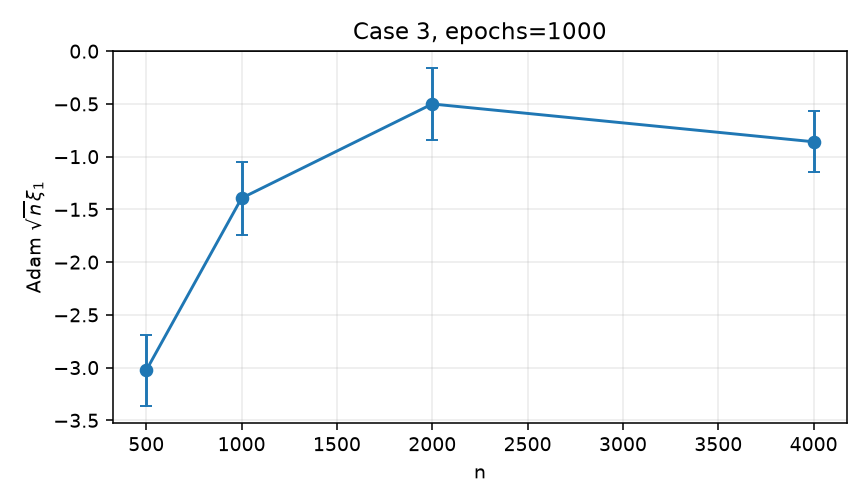

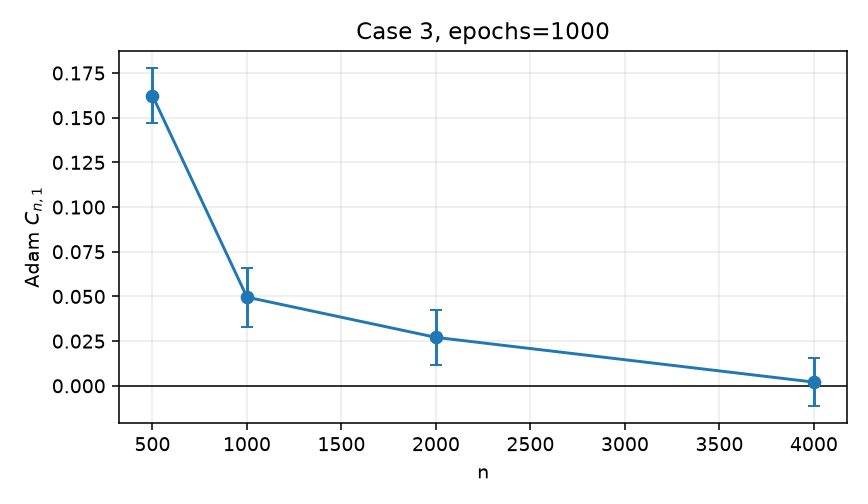

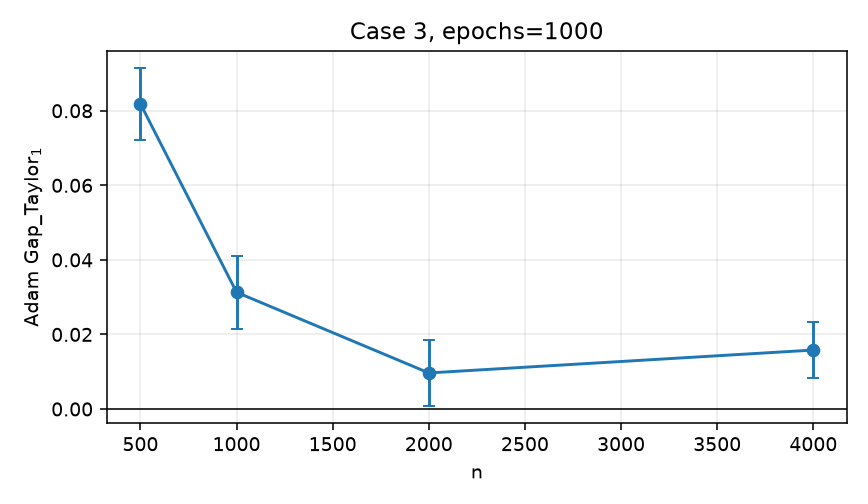

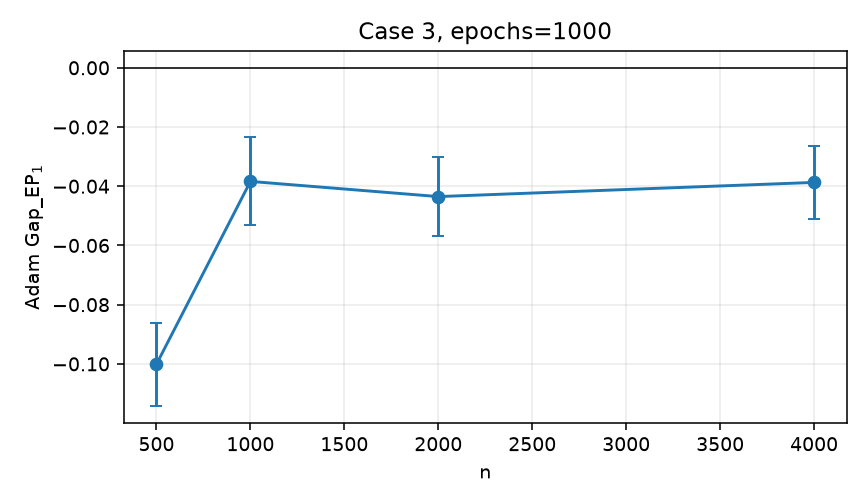

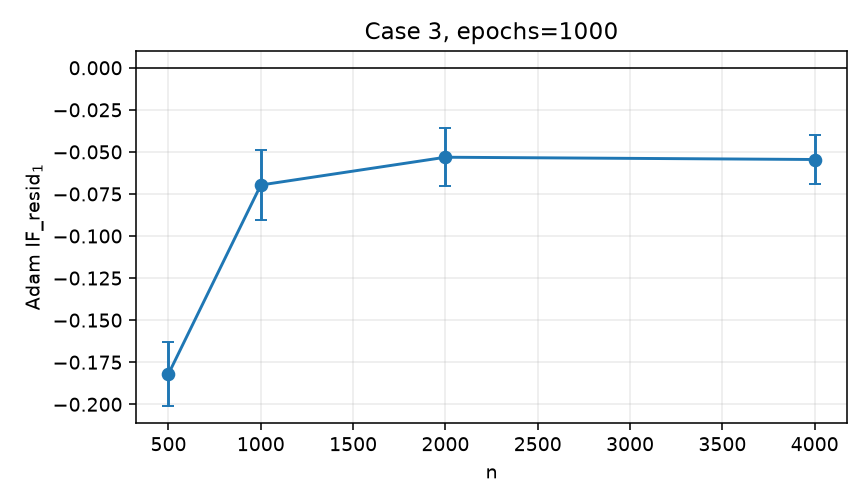

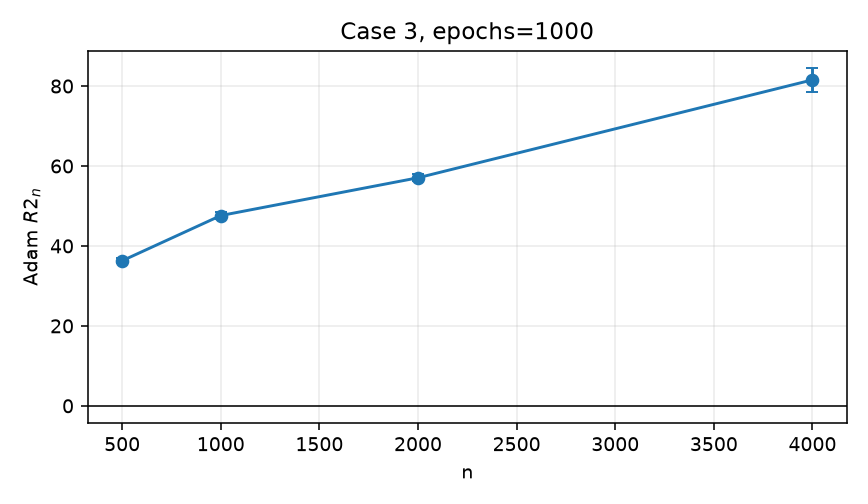

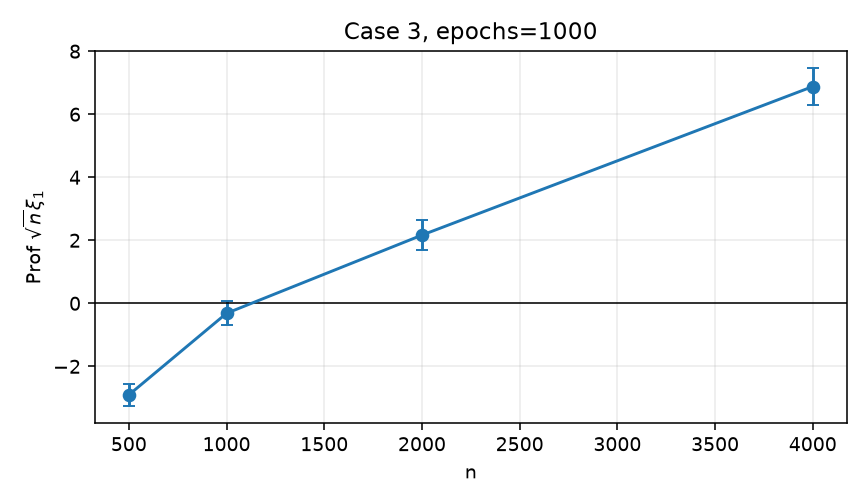

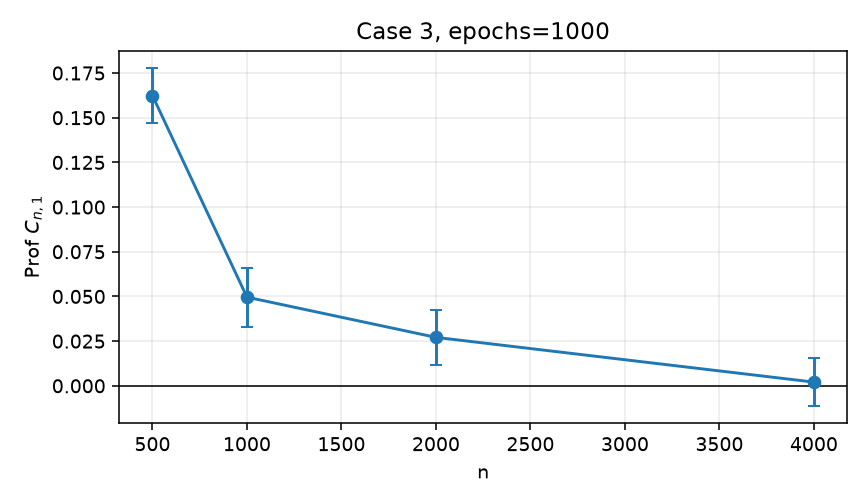

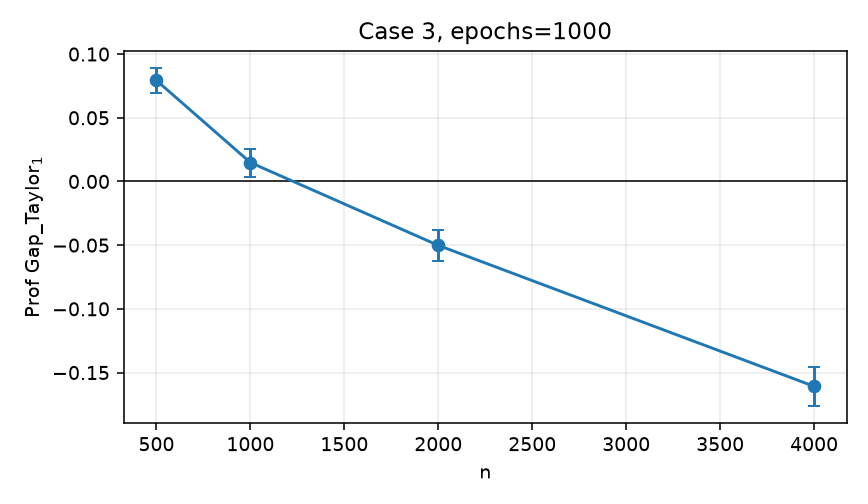

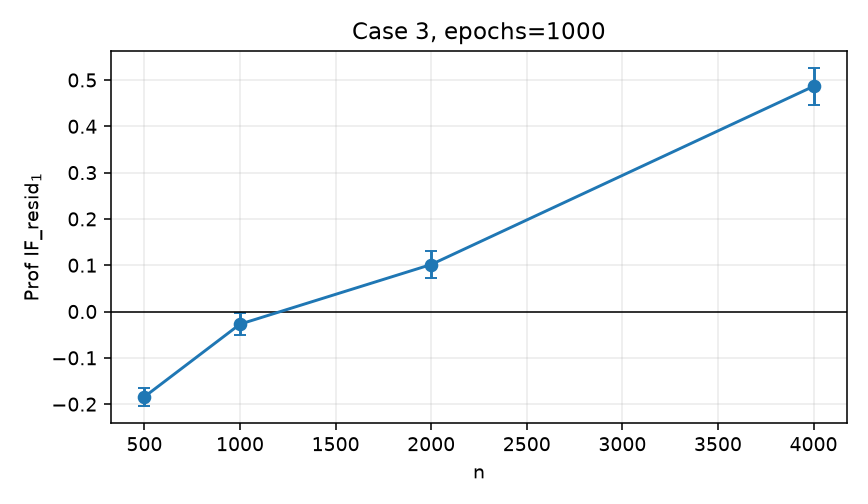

Figures: 10 under C:\Users\Tiansui Tu\Documents\GitHub\dplqr\results\2026-09-11_asymptotic_normality_case3\run_psi_n_if\figures


In [5]:
fig_dir = OUT / "figures"
paths = diag.plot_primary(summary, fig_dir, epochs=FOCUS_EPOCHS) if not summary.empty else []
for path in paths:
    display(Image(filename=str(path)))
print("Figures:", len(paths), "under", fig_dir)


## Reading guide

At 1000 epochs, compare means from $n=2000$ to $n=4000$:

1. $\sqrt{n}\xi_1$ — known non-vanishing scaled bias for $\theta_1$
2. $C_{n,1}$ — Gateaux / orthogonality piece
3. Gap_Taylor$_1$ — first-order Taylor remainder
4. Gap_EP$_1$ — empirical-process identity
5. IF_resid$_1$ — combined linear-representation residual
6. $R2_n$ — nuisance $L^2$ second-order proxy
7. Profiled-$\theta$ columns — whether freezing $\hat m$ and re-solving $\theta$ changes the broken piece

Report which mean fails to approach 0; no automatic asymptotic verdict.


In [6]:
if not summary.empty:
    sub = summary[summary.epochs == FOCUS_EPOCHS].sort_values("n")
    focus = [
        "n", "Q",
        "mean_adam_sn_xi_1", "mcse_adam_sn_xi_1",
        "mean_adam_C_n_1", "mcse_adam_C_n_1",
        "mean_adam_Gap_Taylor_1", "mcse_adam_Gap_Taylor_1",
        "mean_adam_Gap_EP_1", "mcse_adam_Gap_EP_1",
        "mean_adam_IF_resid_1", "mcse_adam_IF_resid_1",
        "mean_adam_R2_n", "mcse_adam_R2_n",
        "mean_prof_sn_xi_1", "mean_prof_C_n_1", "mean_prof_Gap_Taylor_1",
        "mean_prof_IF_resid_1", "mean_prof_R2_n",
    ]
    focus = [c for c in focus if c in sub.columns]
    print(f"Focus @ epochs={FOCUS_EPOCHS}")
    display(sub[focus])
else:
    print("Run analysis first.")


Focus @ epochs=1000


,n,Q,mean_adam_sn_xi_1,mcse_adam_sn_xi_1,mean_adam_C_n_1,mcse_adam_C_n_1,mean_adam_Gap_Taylor_1,mcse_adam_Gap_Taylor_1,mean_adam_Gap_EP_1,mcse_adam_Gap_EP_1,mean_adam_IF_resid_1,mcse_adam_IF_resid_1,mean_adam_R2_n,mcse_adam_R2_n,mean_prof_sn_xi_1,mean_prof_C_n_1,mean_prof_Gap_Taylor_1,mean_prof_IF_resid_1,mean_prof_R2_n
0,500,200,-3.026447,0.336086,0.162379,0.015561,0.081864,0.009668,-0.100109,0.014054,-0.181973,0.018961,36.290920,0.575295,-2.905614,0.162379,0.079280,-0.184072,36.290920
1,1000,200,-1.393665,0.345622,0.049605,0.016558,0.031304,0.009764,-0.038380,0.014835,-0.069683,0.020531,47.601095,0.867190,-0.316757,0.049605,0.014822,-0.027277,47.601095
2,2000,200,-0.500554,0.343279,0.027101,0.015325,0.009669,0.008820,-0.043505,0.013215,-0.053174,0.017245,57.049662,0.893895,2.164516,0.027101,-0.050190,0.101520,57.049662
3,4000,200,-0.859025,0.290704,0.002069,0.013265,0.015808,0.007600,-0.038716,0.012371,-0.054524,0.014488,81.546402,3.024694,6.878657,0.002069,-0.160839,0.486307,81.546402
